<a href="https://colab.research.google.com/github/dewianggrainimeita/PCVK_Ganjil_2026/blob/main/Latihan_integerasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

== LANGKAH PRAKTIKUM D2 ==

In [14]:
#Langkah 1: Import Library
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

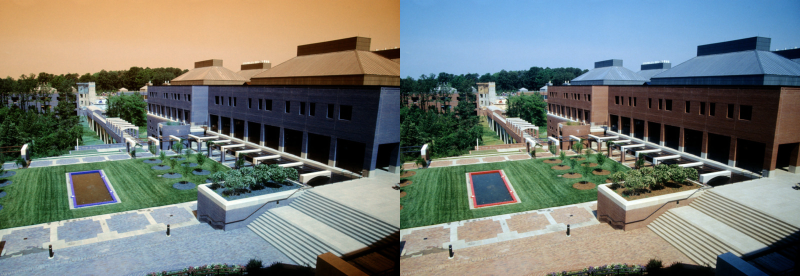

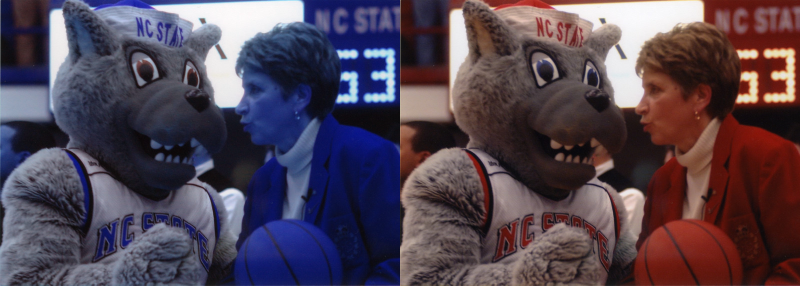

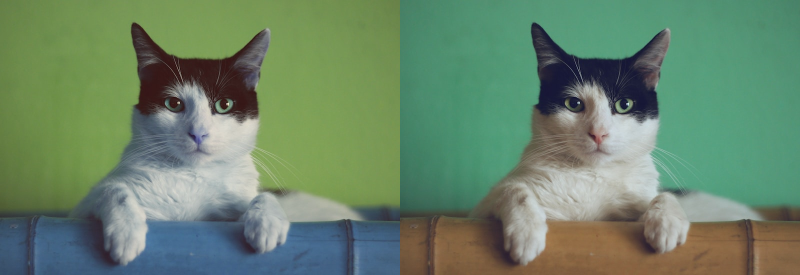

In [13]:
# Langkah 2: Membaca dan Menampilkan Gambar dari URL
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=800" # URL pengganti yang stabil
]

for url in urls:
    try:
        image = io.imread(url)
        image = cv.resize(image, (0,0), fx=0.5, fy=0.5)
        image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        final_frame = cv.hconcat((image, image_2))
        cv2_imshow(final_frame)
        print('\n')
    except Exception as e:
        print(f"Gagal mengunduh gambar dari {url}: {e}\n")

resolusi image: tinggi x lebar  275  x  400


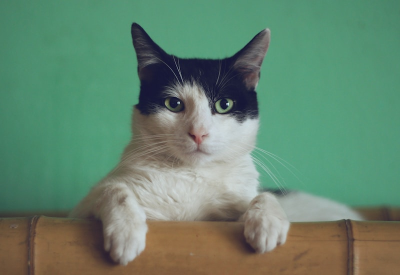

In [16]:
#Langkah 3: Melihat Ukuran File Image
tinggi = image_2.shape[0]
lebar = image_2.shape[1]

print("resolusi image: tinggi x lebar ", tinggi, " x ", lebar)
cv2_imshow(image_2)

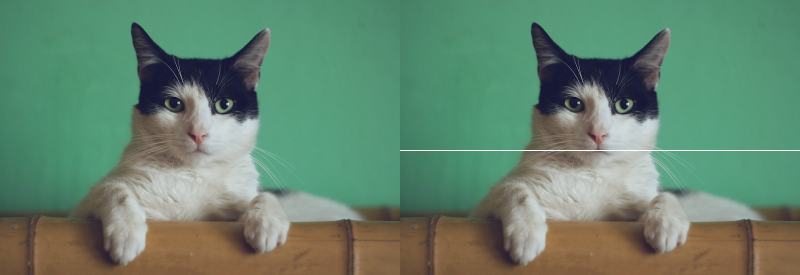

In [15]:
#Langkah 4: Mengakses Pixel dan Memberikan Garis Horizontal
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Membuat garis horizontal berwarna putih di tengah gambar
for y in range(lebar):
    image_3[int((tinggi)/2), y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

== PERTANYAAN PRAKTIKUM D2 ==

1. Mengapa pada modul praktikum ini eksekusi kode Python dilakukan menggunakan Google Colab?
Google Colab menyediakan lingkungan berbasis Jupyter Notebook yang mendukung pustaka AI/Computer Vision, terintegrasi langsung dengan Google Drive dan GitHub, serta menyediakan akses GPU/TPU gratis untuk komputasi berat.

2. Kegunaan setiap library pada langkah 1 dan apakah semua harus digunakan?
Tidak. Yang wajib hanya numpy, cv2, cv2_imshow, dan skimage.io. Library sisanya (pandas, PIL, matplotlib) belum tidak terpakai.

3. Kegunaan image = cv.resize(image, (0,0), fx=0.5, fy=0.5) dan dampaknya jika tidak dilakukan:
Kode ini berfungsi untuk memperkecil resolusi citra menjadi setengahnya (50% dari tinggi dan lebar asli). Jika tidak dilakukan, ukuran tampilan citra akan terlalu besar saat ditampilkan di layar dan akan mengonsumsi memori lebih banyak saat pemrosesan array.

4. Kegunaan kode [255, 255, 255] pada manipulasi pixel:
Kode [255, 255, 255] merepresentasikan nilai intensitas warna tertinggi dari kanal Red, Green, dan Blue (RGB) dengan bit-depth 8-bit. Kombinasi ketiga nilai ini menghasilkan warna putih polos pada piksel yang diakses

5. Keterkaitan antara piksel dan resolusi gambar:
Piksel adalah elemen/unit terkecil pembentuk citra raster. Resolusi menyatakan total kepadatan piksel (tinggi x lebar)
-Resolusi Tinggi: Memiliki jumlah piksel yang lebih banyak, sehingga detail citra tampak tajam dan tidak pecah.
-Resolusi Rendah: Memiliki jumlah piksel lebih sedikit, sehingga gambar terlihat lebih kabur atau berkotak-kotak (pixelated).

== TUGAS PRAKTIKUM D2 ==


2a. Garis Vertikal (Cookies):


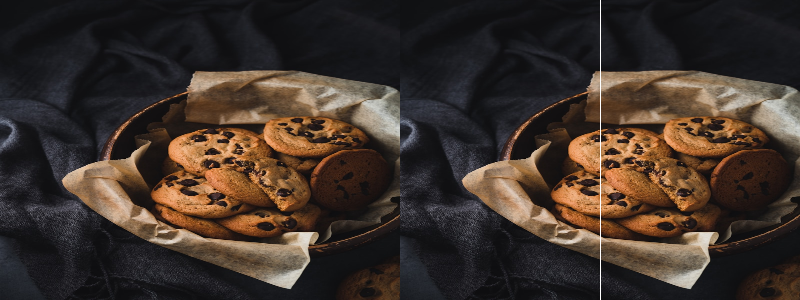


2b. Garis Menyilang Diagonal (Cookies):


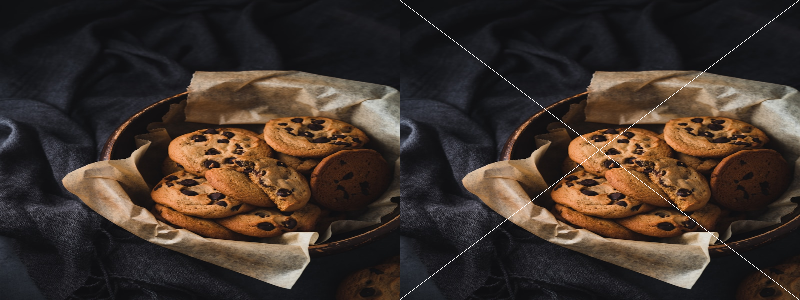


3. Garis Horizontal Panjang Tertentu (Cake):


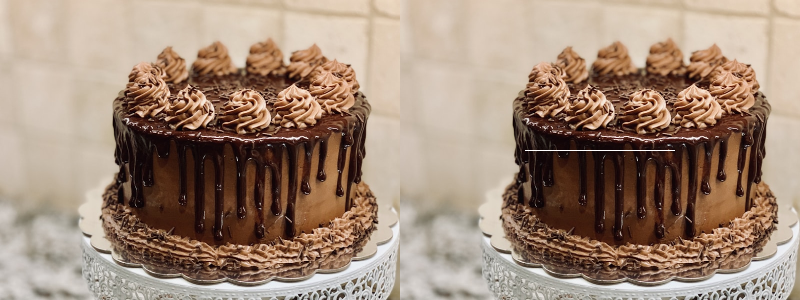


4. Kotak Piksel Warna Putih (Cake):


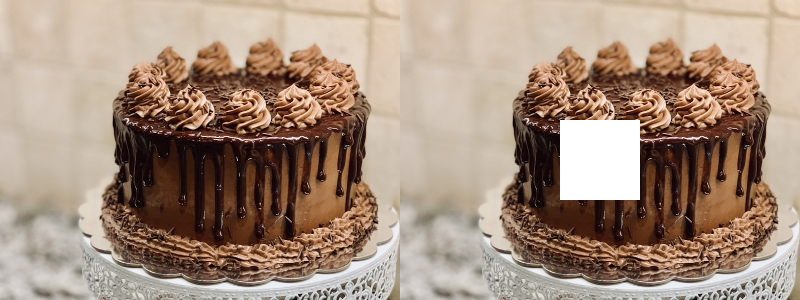

In [17]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
from skimage import io

# URL gambar
url_cookies = "https://images.unsplash.com/photo-1558961363-fa8fdf82db35?w=800"
url_cake = "https://images.unsplash.com/photo-1578985545062-69928b1d9587?w=800"

# NO 2: GARIS VERTIKAL DAN GARIS MENYILANG DIAGONAL (COOKIES)
img_a = io.imread(url_cookies)
img_a = cv.resize(img_a, (400, 300))
img_a = cv.cvtColor(img_a, cv.COLOR_BGR2RGB)

# 2a. Garis Vertikal di Tengah
img_vertikal = img_a.copy()
tinggi, lebar, _ = img_vertikal.shape
for x in range(tinggi):
    img_vertikal[x, int(lebar/2)] = [255, 255, 255]

frame_2a = cv.hconcat((img_a, img_vertikal))
print("2a. Garis Vertikal (Cookies):")
cv2_imshow(frame_2a)

# 2b. Garis Menyilang Diagonal (X)
img_diagonal = img_a.copy()
for i in range(tinggi):
    j1 = int(i * (lebar / tinggi))
    j2 = int((tinggi - 1 - i) * (lebar / tinggi))
    if 0 <= j1 < lebar:
        img_diagonal[i, j1] = [255, 255, 255]
    if 0 <= j2 < lebar:
        img_diagonal[i, j2] = [255, 255, 255]

frame_2b = cv.hconcat((img_a, img_diagonal))
print("\n2b. Garis Menyilang Diagonal (Cookies):")
cv2_imshow(frame_2b)

# NO 3: GARIS HORIZONTAL PUTIH DENGAN PANJANG TERTENTU (CAKE)
img_b = io.imread(url_cake)
img_b = cv.resize(img_b, (400, 300))
img_b = cv.cvtColor(img_b, cv.COLOR_BGR2RGB)

img_horiz = img_b.copy()
tinggi_b, lebar_b, _ = img_horiz.shape

panjang_garis = 150
start_x = (lebar_b - panjang_garis) // 2
end_x = start_x + panjang_garis

for y in range(start_x, end_x):
    img_horiz[int(tinggi_b / 2), y] = [255, 255, 255]

frame_3 = cv.hconcat((img_b, img_horiz))
print("\n3. Garis Horizontal Panjang Tertentu (Cake):")
cv2_imshow(frame_3)

# NO 4: KOTAK PIKSEL WARNA PUTIH DI SEMBARANG TEMPAT (CAKE)
img_box = img_b.copy()

y_start, y_end = 120, 200
x_start, x_end = 160, 240

for i in range(y_start, y_end):
    for j in range(x_start, x_end):
        img_box[i, j] = [255, 255, 255]

frame_4 = cv.hconcat((img_b, img_box))
print("\n4. Kotak Piksel Warna Putih (Cake):")
cv2_imshow(frame_4)